# Analysis notebook for LYNX ML Model

In [14]:
import numpy as np
import pandas as pd
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import json
import math

In [2]:
DES_PARAM_VALUES = {
    "des_top_descriptor_reqs": [2, 4, 8, 16],
    "des_top_memloader_reqs": [16, 32, 64, 128],
    "des_cr_rocc_commands": [2, 4, 8],
    "des_dth_l1_reqs": [2, 4, 8, 16],
    "des_dth_fd_reqs": [2, 4, 8, 16],
    "des_dth_fd_resps": [2, 4, 8, 16],
    "des_fw_l1_reqs": [2, 4, 8, 16],
    "des_ml_buf_info_q": [8, 16, 32, 64],
    "des_ml_load_info_q": [128, 256, 512, 1024],
}

SER_PARAM_VALUES = {
    "ser_field_handlers": [2, 4, 6, 8],
    "ser_cr_rocc_commands": [2, 4, 6, 8],
    "ser_dth_hasbits_reqs": [2, 4, 8],
    "ser_dth_descriptor_reqs": [2, 4, 8, 16],
    "ser_dth_reg_resps": [5, 10, 20],
    "ser_dth_reqs_meta": [2, 4, 8, 16],
    "ser_dth_fh_outputs": [2, 4, 8, 16],
    "ser_mw_write_input": [2, 4, 8, 16],
    "ser_mw_write_inject": [2, 4, 8, 16],
    "ser_mw_write_ptrs": [5, 10, 20],
}

# Deserializer Simulation Results

In [45]:
df_ubuntu_results = pd.read_csv('sim_results/des_sweep_results_ubuntu_v1.csv')
df_rhel_results = pd.read_csv('sim_results/des_sweep_results_rhel_v1.csv')

## Construct combined results

In [47]:
config_columns = list(SER_PARAM_VALUES.keys()) + list(DES_PARAM_VALUES.keys())

In [48]:
program_columns = ['bench', 'op']

In [49]:
# Concatenate the two dataframes
combined_df = pd.concat([df_ubuntu_results, df_rhel_results], ignore_index=True)

# Check for duplicates across all columns
assert combined_df[program_columns + config_columns].drop_duplicates().shape[0] == combined_df.shape[0]

In [50]:
combined_df.to_csv('sim_results/des_combined_results.csv', index=False)

In [52]:
combined_df['op'].value_counts()

op
des    16376
Name: count, dtype: int64

## Construct unique config dataset

In [36]:
from collections import Counter

# For each unique config, randomly pick a benchmark such that the overall benchmark distribution is as uniform as possible.
# We'll use a greedy approach: for each config, assign it to the currently least-represented benchmark it possesses.

# First, find all unique configs (ignoring benchmark), mapping each config to possible benchmark rows
group_cols = config_columns
bench_choices_by_config = combined_df.groupby(group_cols)['bench'].unique().reset_index()
configs = bench_choices_by_config.to_dict(orient='records')

# Prepare data structure for mapping chosen config -> selected row
selected_row_indices = []
bench_count = Counter()

for conf in configs:
    # Get the boolean mask for all rows matching this config (across all benches)
    config_mask = (combined_df[group_cols] == pd.Series({k: conf[k] for k in group_cols})).all(axis=1)
    config_rows = combined_df[config_mask]
    benches = list(conf['bench'])
    # For each config, select the bench with current minimum count
    min_bench = min(benches, key=lambda b: bench_count[b])
    bench_count[min_bench] += 1
    # Select all rows for this (config, min_bench)
    selected = config_rows[config_rows['bench'] == min_bench]
    selected_row_indices.extend(selected.index.tolist())

# Build DataFrame (retaining all columns and all info for the selected rows)
unique_configs_df = combined_df.loc[selected_row_indices].reset_index(drop=True)
print(f'Shape of unique_configs_df: {unique_configs_df.shape}')

Shape of unique_configs_df: (3101, 30)


In [37]:
# Check if there are duplicates in the 'config_name' column
duplicates = unique_configs_df['config_name'].duplicated().any()
print(f"Are there duplicates in 'config_name'? {duplicates}")

Are there duplicates in 'config_name'? False


In [38]:
unique_configs_df.groupby('bench').size()

bench
bench0    517
bench1    517
bench2    517
bench3    517
bench4    517
bench5    516
dtype: int64

In [39]:
unique_configs_df.to_csv('sim_results/des_unique_configs.csv', index=False)

## Train/test split 0.25

In [21]:
df = pd.read_csv('results/hpb_only/deserializer_test_0.25/deserializer_test_predictions.csv')

In [22]:
df['error'] = abs(df['predicted_throughput'] - df['actual_throughput']) / df['actual_throughput'] * 100

In [23]:
full_df = pd.read_csv('data/hpb_only/des_unique_configs_training_data.csv')
train_df = full_df[~full_df['config_name'].isin(df['config_name'])]
print(train_df['bench'].value_counts())
print(df['bench'].value_counts())

bench
bench1    396
bench2    391
bench3    391
bench4    385
bench0    382
bench5    380
Name: count, dtype: int64
bench
bench5    136
bench0    135
bench4    132
bench2    126
bench3    126
bench1    121
Name: count, dtype: int64


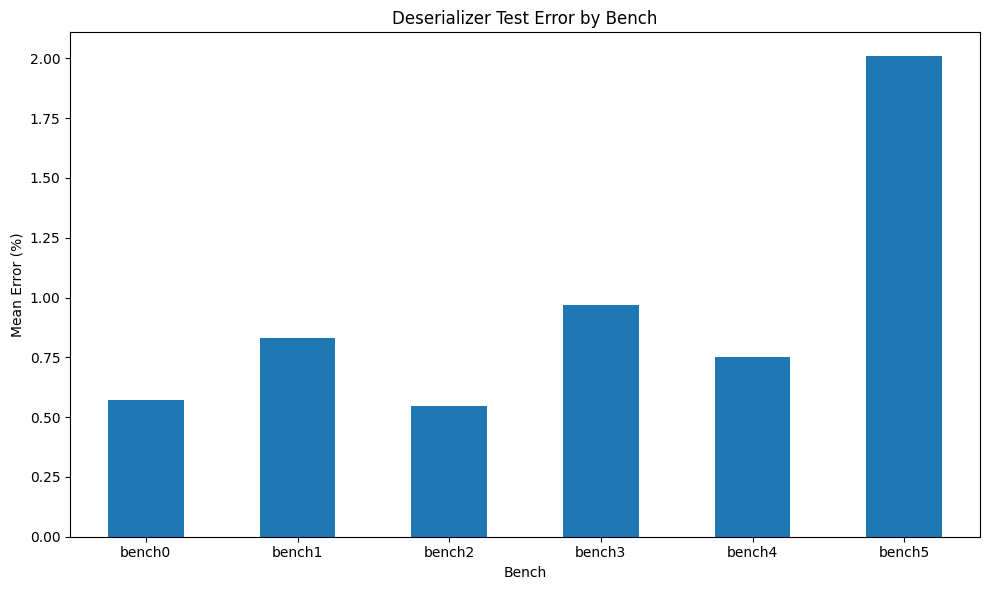

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
bench_error = df.groupby('bench')['error'].mean()
bench_error.plot(kind='bar', ax=ax)
ax.set_xlabel('Bench')
ax.set_ylabel('Mean Error (%)')
ax.set_title('Deserializer Test Error by Bench')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("results/hpb_only/deserializer_test_0.25/deserializer_test_bench_error.png", bbox_inches='tight')

## Train/Test Sweep

In [36]:
summary_file = "sweep_results/hpb_only/train_test_split_des/summary.txt"
with open(summary_file, "r") as f:
    summary = f.read()

deserializer_test_error = defaultdict(dict)
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    if "Test size: " in line:
        pat = r"Test size: ([^|]+)"
        m = re.search(pat, line)
        if m:
            test_size = float(m.group(1))
            i += 1
            line = lines[i]
            percent_error = float(line.split("Final Percent Error: ")[1].split("%")[0].strip())
            deserializer_test_error[test_size] = percent_error
    i += 1

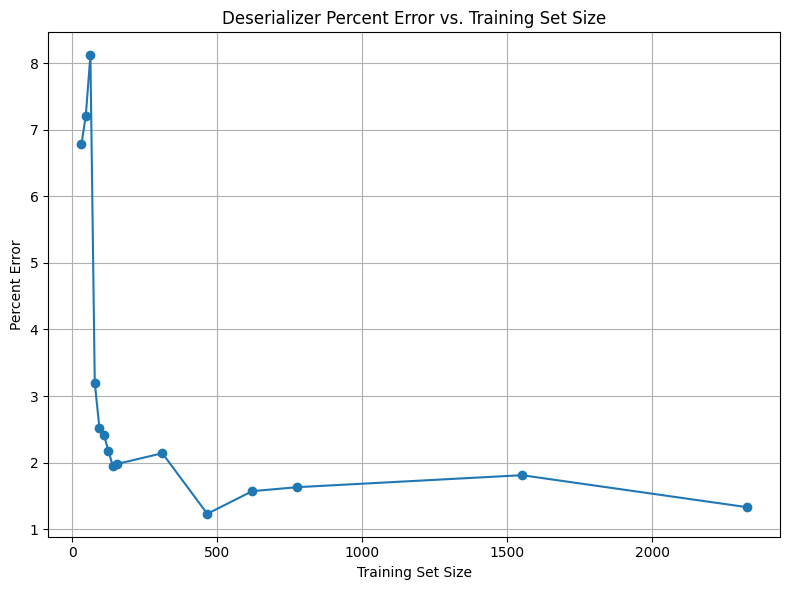

In [ ]:
dataset_size = 3101
test_proportions = deserializer_test_error.keys()
errors = [deserializer_test_error[test_proportion] for test_proportion in test_proportions]
test_sizes = [math.ceil(dataset_size * test_proportion) for test_proportion in test_proportions]
train_sizes = [dataset_size - test_size for test_size in test_sizes]

fig, ax = plt.subplots(figsize=(8, 6))
# Sort test_sizes for a smooth plot
ax.plot(train_sizes, errors, marker='o')
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Percent Error")
ax.set_title("Deserializer Percent Error vs. Training Set Size")
plt.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/hpb_only/train_test_split_des/deserializer_train_test_split_error.png", bbox_inches='tight')
plt.show()

### No features

In [ ]:
summary_file = "sweep_results/hpb_only/train_test_split_des_no_feat/summary.txt"
with open(summary_file, "r") as f:
    summary = f.read()

deserializer_no_feat_test_error = {}
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    if "Test size: " in line:
            pat = r"Test size: ([^|]+)"
            m = re.search(pat, line)
            if m:
                test_size = float(m.group(1))
                i += 1
                line = lines[i]
                try:
                    percent_error = float(line.split("Final Percent Error: ")[1].split("%")[0].strip())
                    deserializer_no_feat_test_error[test_size] = percent_error
                except:
                    print(f"Could not find an error for test_size {test_size}")
    i += 1

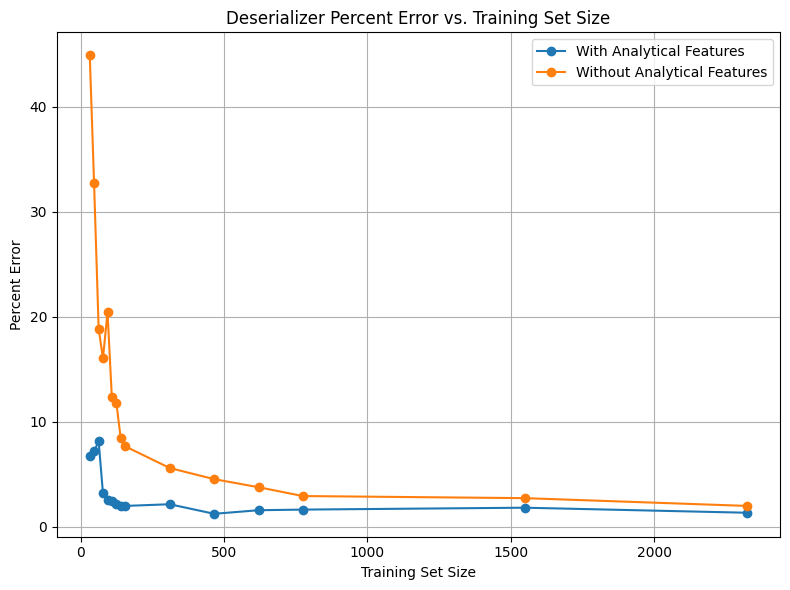

In [39]:
dataset_size = 3101
test_proportions = deserializer_test_error.keys()
errors = [deserializer_test_error[test_proportion] for test_proportion in test_proportions]
test_sizes = [math.ceil(dataset_size * test_proportion) for test_proportion in test_proportions]
train_sizes = [dataset_size - test_size for test_size in test_sizes]

no_feat_test_proportions = deserializer_no_feat_test_error.keys()
no_feat_errors = [deserializer_no_feat_test_error[test_proportion] for test_proportion in no_feat_test_proportions]
no_feat_test_sizes = [math.ceil(dataset_size * test_proportion) for test_proportion in no_feat_test_proportions]
no_feat_train_sizes = [dataset_size - test_size for test_size in no_feat_test_sizes]

fig, ax = plt.subplots(figsize=(8, 6))
# Sort test_sizes for a smooth plot
ax.plot(train_sizes, errors, marker='o', label="With Analytical Features")
ax.plot(no_feat_train_sizes, no_feat_errors, marker='o', label="Without Analytical Features")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Percent Error")
ax.set_title("Deserializer Percent Error vs. Training Set Size")
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/hpb_only/train_test_split_des_no_feat/deserializer_train_test_split_error.png", bbox_inches='tight')
plt.show()

## Onboarding Cost

In [18]:
summary_file = "sweep_results/ood_bench_onboarding_des/summary.txt"
with open(summary_file, "r") as f:
    summary = f.read()

deserializer_onboarding_cost = defaultdict(dict)
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    if "OOD benchmark: " in line:
        pat = r"OOD benchmark: ([^|]+) \| OOD train size: (\d+)"
        m = re.search(pat, line)
        if m:
            benchmark = m.group(1)
            ood_train_size = int(m.group(2))
            i += 1
            line = lines[i]
            percent_error = float(line.split("Final Percent Error: ")[1].split("%")[0].strip())
            deserializer_onboarding_cost[benchmark][ood_train_size] = percent_error
    i += 1

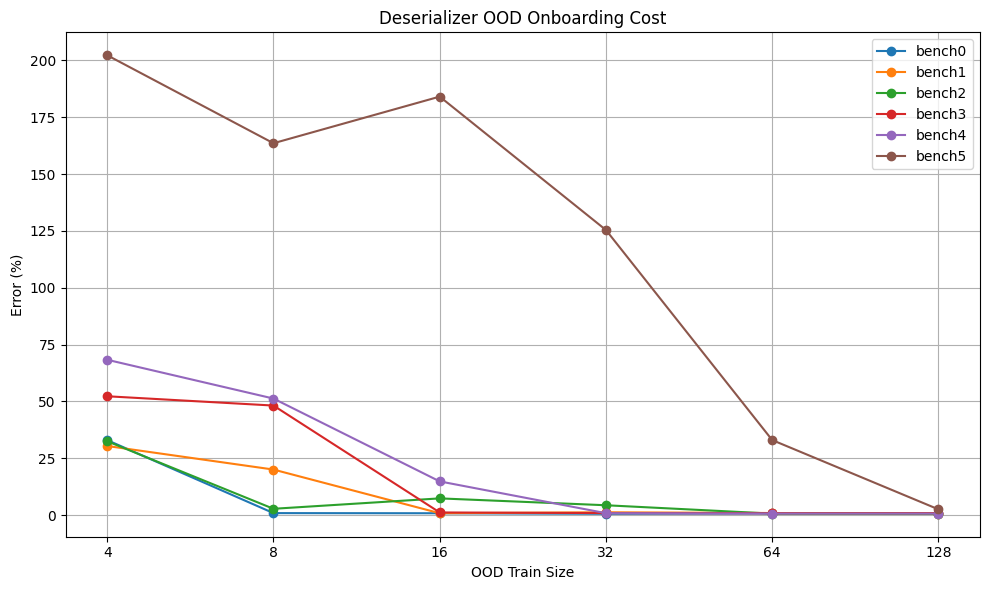

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# Include all benchmarks, including bench5
filtered_benchmarks = deserializer_onboarding_cost

# Filter out train_size=0 from all curve points and xticks
all_xs = sorted({x for benchmark, errors in filtered_benchmarks.items() for x in errors.keys() if x != 0})
x_positions = np.arange(len(all_xs))
x_lookup = {x: i for i, x in enumerate(all_xs)}

for benchmark, errors in filtered_benchmarks.items():
    xs = sorted([x for x in errors.keys() if x != 0])
    ys = [errors[x] for x in xs]
    positions = [x_lookup[x] for x in xs]
    ax.plot(positions, ys, marker='o', label=benchmark)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(all_xs)
ax.set_xlabel("OOD Train Size")
ax.set_ylabel("Error (%)")
ax.set_title("Deserializer OOD Onboarding Cost")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/ood_bench_onboarding_des/onboarding_cost.png", bbox_inches='tight')

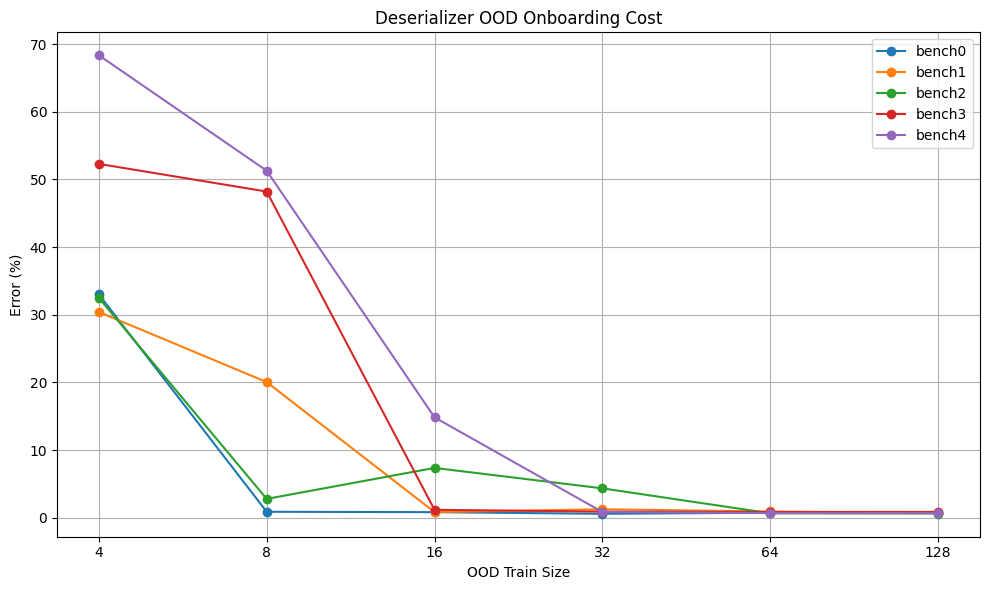

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ignore "bench5" everywhere
filtered_benchmarks = {b: e for b, e in deserializer_onboarding_cost.items() if b != "bench5"}

# Filter out train_size=0 from all curve points and xticks
all_xs = sorted({x for benchmark, errors in filtered_benchmarks.items() for x in errors.keys() if x != 0})
x_positions = np.arange(len(all_xs))
x_lookup = {x: i for i, x in enumerate(all_xs)}

for benchmark, errors in filtered_benchmarks.items():
    xs = sorted([x for x in errors.keys() if x != 0])
    ys = [errors[x] for x in xs]
    positions = [x_lookup[x] for x in xs]
    ax.plot(positions, ys, marker='o', label=benchmark)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(all_xs)
ax.set_xlabel("OOD Train Size")
ax.set_ylabel("Error (%)")
ax.set_title("Deserializer OOD Onboarding Cost")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/ood_bench_onboarding_des/onboarding_cost_without_bench5.png", bbox_inches='tight')

## Full Training Analysis

In [42]:
df = pd.read_csv("results/deserializer/deserializer_final_predictions.csv")

In [43]:
df['error'] = abs(df['predicted_throughput'] - df['actual_throughput']) / df['actual_throughput'] * 100

NameError: name 'df' is not defined

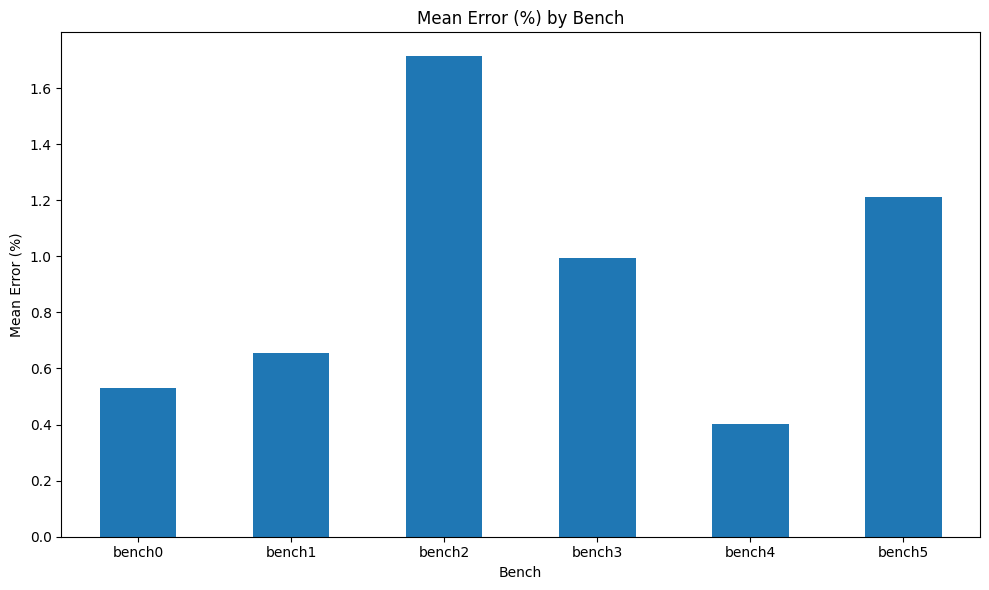

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
bench_error = df.groupby('bench')['error'].mean()
bench_error.plot(kind='bar', ax=ax)
ax.set_xlabel('Bench')
ax.set_ylabel('Mean Error (%)')
ax.set_title('Mean Error (%) by Bench')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("results/deserializer/deserializer_bench_error.png", bbox_inches='tight')

## Pareto Front

### NGSA Search

In [56]:
with open("results/deserializer/pareto_front.json", "r") as f:
    pareto_front = json.load(f)

In [57]:
pareto_points = []
default_pareto_point = {
    'predicted_throughput': pareto_front['baseline']['predicted_throughput_gbits_per_sec'], 
    'predicted_cost': pareto_front['baseline']['predicted_cost']
}
for point in pareto_front['pareto_front']:
    pareto_points.append({
        'predicted_throughput': point['predicted_throughput_gbits_per_sec'],
        'predicted_cost': point['predicted_cost'],
        'validation_candidate': point['validation_candidate']
    })

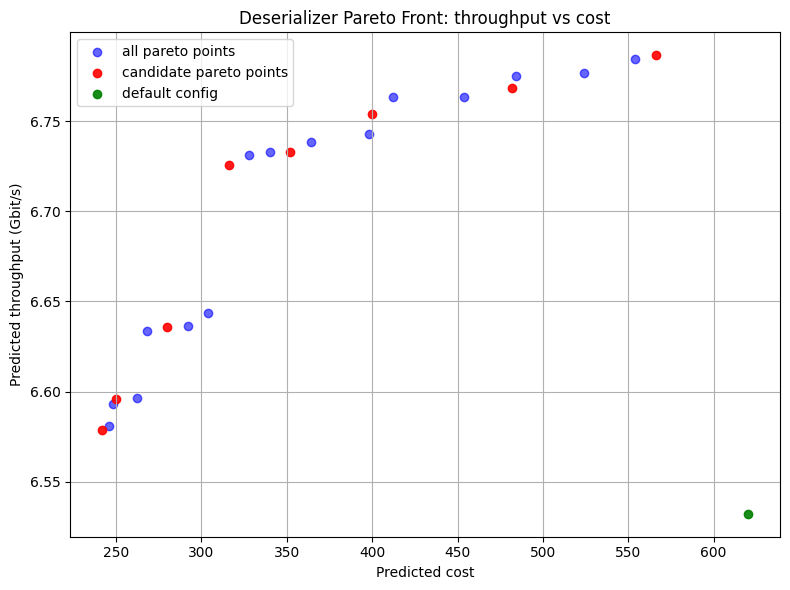

In [58]:
cost = np.array([p["predicted_cost"] for p in pareto_points])
throughput = np.array([p["predicted_throughput"] for p in pareto_points])
is_validation = np.array([p.get("validation_candidate", False) for p in pareto_points])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost[~is_validation], throughput[~is_validation], c="blue", label="all pareto points", alpha=0.6)
ax.scatter(cost[is_validation], throughput[is_validation], c="red", label="candidate pareto points", alpha=0.9)

ax.scatter(default_pareto_point['predicted_cost'], default_pareto_point['predicted_throughput'], c="green", label="default config", alpha=0.9)

ax.set_xlabel("Predicted cost")
ax.set_ylabel("Predicted throughput (Gbit/s)")
ax.set_title("Deserializer Pareto Front: throughput vs cost")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
fig.savefig("results/deserializer/deserializer_throughput_vs_cost.png", bbox_inches="tight")

### Exhaustive Search

In [6]:
with open("results/hpb_only/deserializer_train_only/exhaustive_pareto_front.json", "r") as f:
    pareto_front = json.load(f)

In [7]:
pareto_points = []
default_pareto_point = {
    'predicted_throughput': pareto_front['baseline']['predicted_throughput_gbits_per_sec'], 
    'predicted_cost': pareto_front['baseline']['predicted_cost']
}
for point in pareto_front['pareto_front']:
    pareto_points.append({
        'predicted_throughput': point['predicted_throughput_gbits_per_sec'],
        'predicted_cost': point['predicted_cost'],
        'validation_candidate': point['validation_candidate']
    })

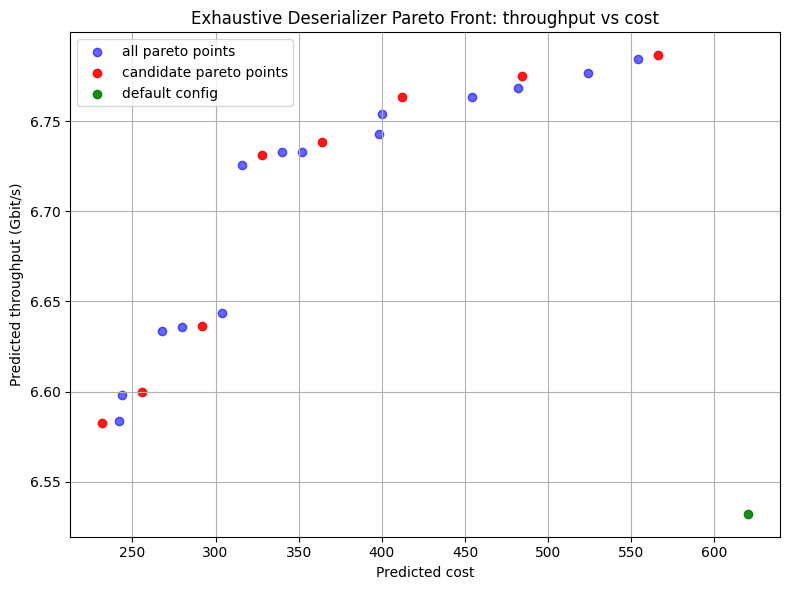

In [9]:
cost = np.array([p["predicted_cost"] for p in pareto_points])
throughput = np.array([p["predicted_throughput"] for p in pareto_points])
is_validation = np.array([p.get("validation_candidate", False) for p in pareto_points])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost[~is_validation], throughput[~is_validation], c="blue", label="all pareto points", alpha=0.6)
ax.scatter(cost[is_validation], throughput[is_validation], c="red", label="candidate pareto points", alpha=0.9)

ax.scatter(default_pareto_point['predicted_cost'], default_pareto_point['predicted_throughput'], c="green", label="default config", alpha=0.9)

ax.set_xlabel("Predicted cost")
ax.set_ylabel("Predicted throughput (Gbit/s)")
ax.set_title("Exhaustive Deserializer Pareto Front: throughput vs cost")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
fig.savefig("results/hpb_only/deserializer_train_only/exhaustive_pareto_front.png", bbox_inches="tight")

# Serializer Simulation Results

In [40]:
df_ubuntu_results = pd.read_csv('sim_results/ser_sweep_results_ubuntu_v1.csv')
df_rhel_results = pd.read_csv('sim_results/ser_sweep_results_rhel_v1.csv')

## Construct combined results

In [41]:
config_columns = list(SER_PARAM_VALUES.keys()) + list(DES_PARAM_VALUES.keys())

In [42]:
program_columns = ['bench', 'op']

In [43]:
# Concatenate the two dataframes
combined_df = pd.concat([df_ubuntu_results, df_rhel_results], ignore_index=True)

# Check for duplicates across all columns
assert combined_df[program_columns + config_columns].drop_duplicates().shape[0] == combined_df.shape[0]

In [44]:
combined_df.to_csv('sim_results/ser_combined_results.csv', index=False)

## Train/test split 0.25

In [25]:
df = pd.read_csv('results/hpb_only/serializer_test_0.25/serializer_test_predictions.csv')

In [26]:
df['error'] = abs(df['predicted_throughput'] - df['actual_throughput']) / df['actual_throughput'] * 100

In [27]:
full_df = pd.read_csv('data/hpb_only/ser_training_data.csv')
train_df = full_df[~full_df['config_name'].isin(df['config_name'])]
print(train_df['bench'].value_counts())
print(df['bench'].value_counts())

bench
bench2    264
bench4    261
bench0    259
bench1    255
bench5    252
bench3    245
Name: count, dtype: int64
bench
bench0    93
bench3    92
bench2    90
bench1    82
bench4    78
bench5    77
Name: count, dtype: int64


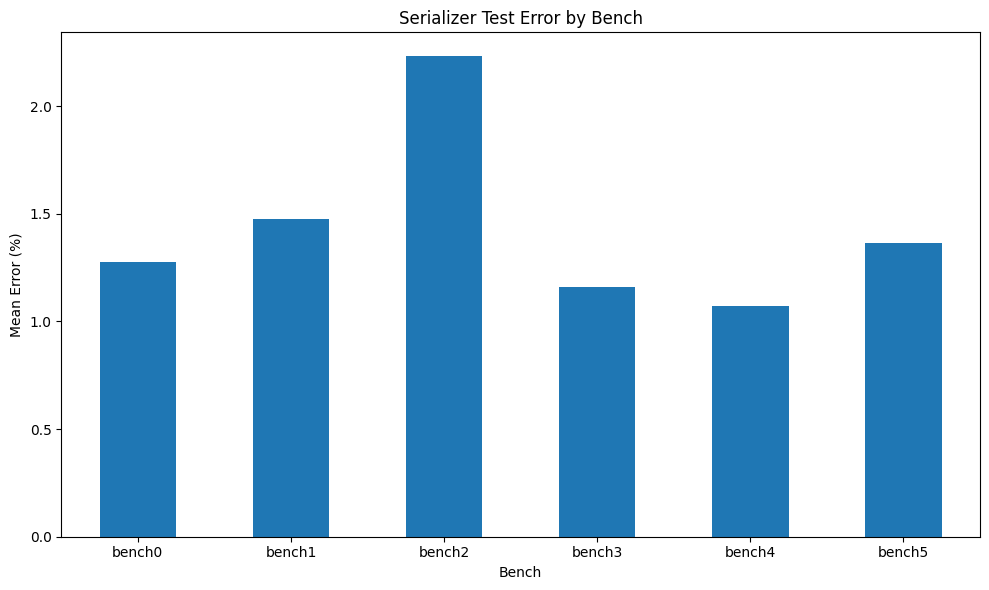

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
bench_error = df.groupby('bench')['error'].mean()
bench_error.plot(kind='bar', ax=ax)
ax.set_xlabel('Bench')
ax.set_ylabel('Mean Error (%)')
ax.set_title('Serializer Test Error by Bench')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("results/hpb_only/serializer_test_0.25/serializer_test_bench_error.png", bbox_inches='tight')

## Train/Test Sweep

In [30]:
summary_file = "sweep_results/hpb_only/train_test_split_ser/summary.txt"
with open(summary_file, "r") as f:
    summary = f.read()

serializer_test_error = defaultdict(dict)
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    if "Test size: " in line:
        pat = r"Test size: ([^|]+)"
        m = re.search(pat, line)
        if m:
            test_size = float(m.group(1))
            i += 1
            line = lines[i]
            percent_error = float(line.split("Final Percent Error: ")[1].split("%")[0].strip())
            serializer_test_error[test_size] = percent_error
    i += 1

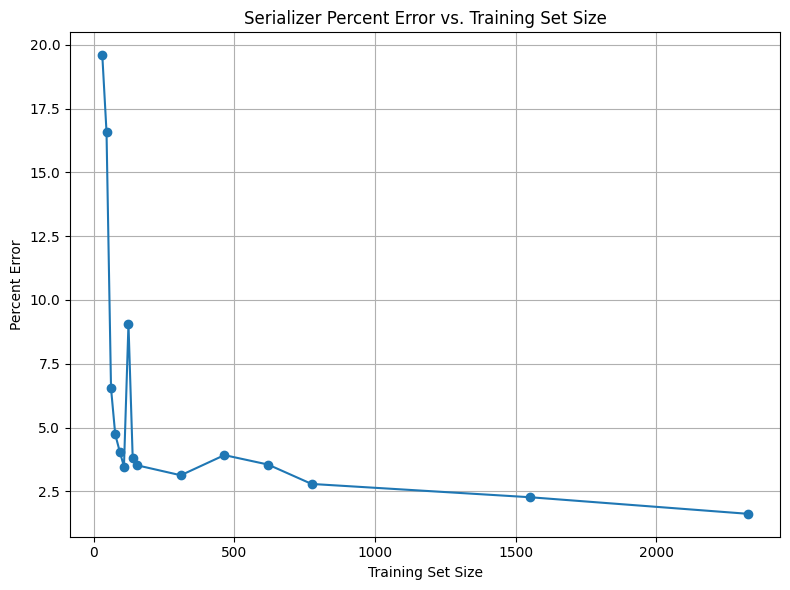

In [31]:
dataset_size = 3101
test_proportions = serializer_test_error.keys()
errors = [serializer_test_error[test_proportion] for test_proportion in test_proportions]
test_sizes = [math.ceil(dataset_size * test_proportion) for test_proportion in test_proportions]
train_sizes = [dataset_size - test_size for test_size in test_sizes]

fig, ax = plt.subplots(figsize=(8, 6))
# Sort test_sizes for a smooth plot
ax.plot(train_sizes, errors, marker='o')
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Percent Error")
ax.set_title("Serializer Percent Error vs. Training Set Size")
plt.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/hpb_only/train_test_split_ser/serializer_train_test_split_error.png", bbox_inches='tight')
plt.show()

### No features

In [32]:
summary_file = "sweep_results/hpb_only/train_test_split_ser_no_feat/summary.txt"
with open(summary_file, "r") as f:
    summary = f.read()

serializer_no_feat_test_error = {}
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    if "Test size: " in line:
            pat = r"Test size: ([^|]+)"
            m = re.search(pat, line)
            if m:
                test_size = float(m.group(1))
                i += 1
                line = lines[i]
                try:
                    percent_error = float(line.split("Final Percent Error: ")[1].split("%")[0].strip())
                    serializer_no_feat_test_error[test_size] = percent_error
                except:
                    print(f"Could not find an error for test_size {test_size}")
    i += 1

Could not find an error for test_size 0.985
Could not find an error for test_size 0.99


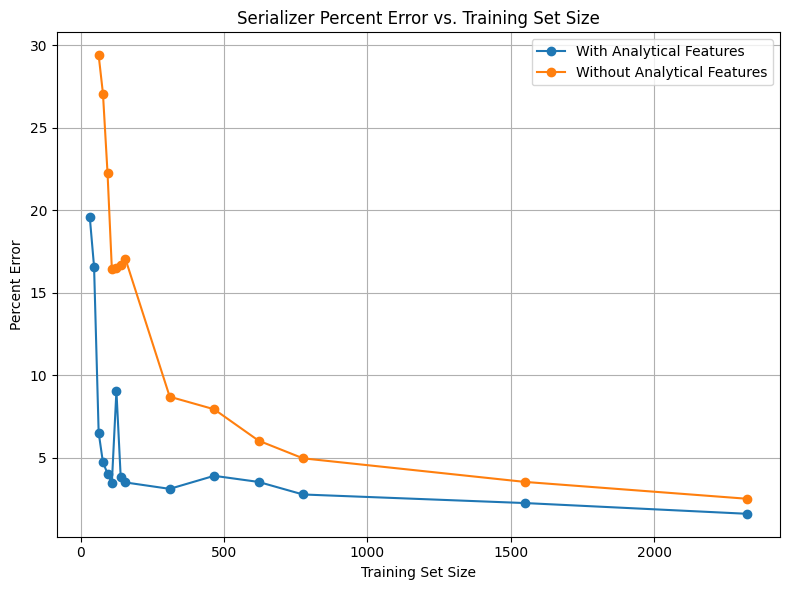

In [34]:
dataset_size = 3101
test_proportions = serializer_test_error.keys()
errors = [serializer_test_error[test_proportion] for test_proportion in test_proportions]
test_sizes = [math.ceil(dataset_size * test_proportion) for test_proportion in test_proportions]
train_sizes = [dataset_size - test_size for test_size in test_sizes]

no_feat_test_proportions = serializer_no_feat_test_error.keys()
no_feat_errors = [serializer_no_feat_test_error[test_proportion] for test_proportion in no_feat_test_proportions]
no_feat_test_sizes = [math.ceil(dataset_size * test_proportion) for test_proportion in no_feat_test_proportions]
no_feat_train_sizes = [dataset_size - test_size for test_size in no_feat_test_sizes]

fig, ax = plt.subplots(figsize=(8, 6))
# Sort test_sizes for a smooth plot
ax.plot(train_sizes, errors, marker='o', label="With Analytical Features")
ax.plot(no_feat_train_sizes, no_feat_errors, marker='o', label="Without Analytical Features")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Percent Error")
ax.set_title("Serializer Percent Error vs. Training Set Size")
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/hpb_only/train_test_split_ser_no_feat/serializer_train_test_split_error.png", bbox_inches='tight')
plt.show()

## Onboarding Cost

In [21]:
summary_file = "sweep_results/ood_bench_onboarding_ser/summary.txt"
with open(summary_file, "r") as f:
    summary = f.read()

serializer_onboarding_cost = defaultdict(dict)
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    if "OOD benchmark: " in line:
        pat = r"OOD benchmark: ([^|]+) \| OOD train size: (\d+)"
        m = re.search(pat, line)
        if m:
            benchmark = m.group(1)
            ood_train_size = int(m.group(2))
            i += 1
            line = lines[i]
            percent_error = float(line.split("Final Percent Error: ")[1].split("%")[0].strip())
            serializer_onboarding_cost[benchmark][ood_train_size] = percent_error
    i += 1

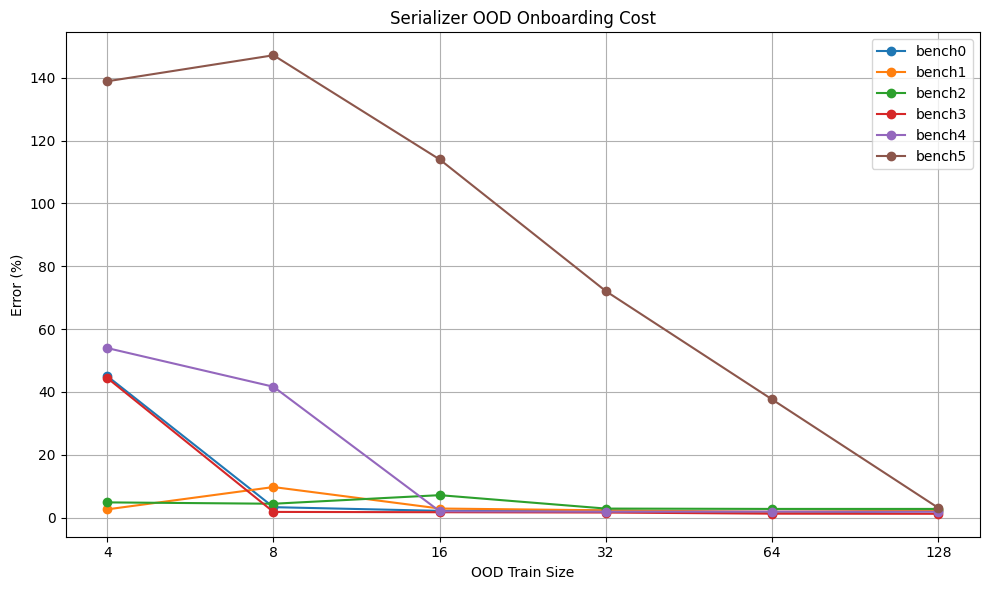

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Include all benchmarks, including bench5
filtered_benchmarks = serializer_onboarding_cost

# Filter out train_size=0 from all curve points and xticks
all_xs = sorted({x for benchmark, errors in filtered_benchmarks.items() for x in errors.keys() if x != 0})
x_positions = np.arange(len(all_xs))
x_lookup = {x: i for i, x in enumerate(all_xs)}

for benchmark, errors in filtered_benchmarks.items():
    xs = sorted([x for x in errors.keys() if x != 0])
    ys = [errors[x] for x in xs]
    positions = [x_lookup[x] for x in xs]
    ax.plot(positions, ys, marker='o', label=benchmark)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(all_xs)
ax.set_xlabel("OOD Train Size")
ax.set_ylabel("Error (%)")
ax.set_title("Serializer OOD Onboarding Cost")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/ood_bench_onboarding_ser/onboarding_cost.png", bbox_inches='tight')

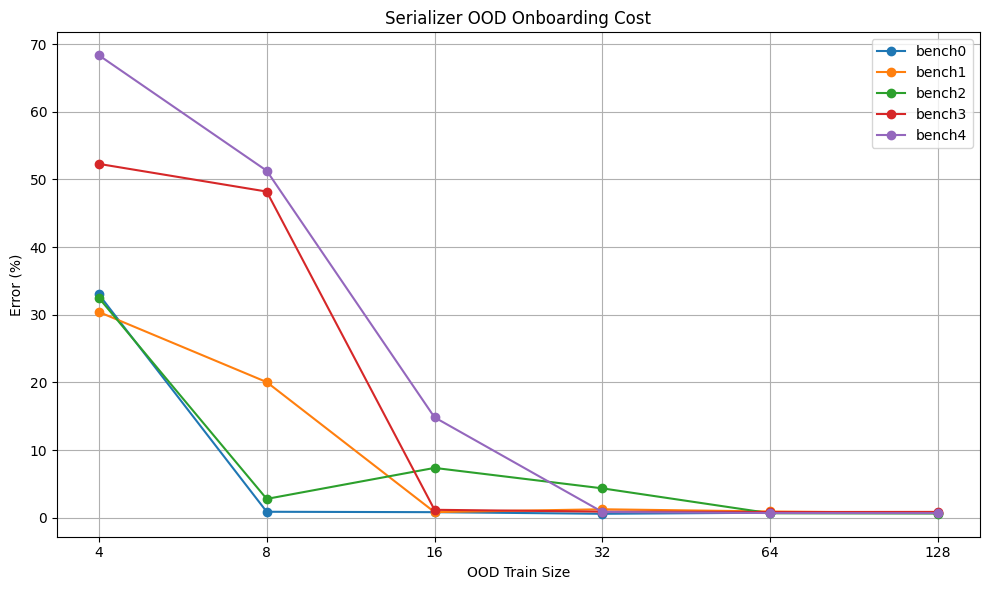

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ignore "bench5" everywhere
filtered_benchmarks = {b: e for b, e in deserializer_onboarding_cost.items() if b != "bench5"}

# Filter out train_size=0 from all curve points and xticks
all_xs = sorted({x for benchmark, errors in filtered_benchmarks.items() for x in errors.keys() if x != 0})
x_positions = np.arange(len(all_xs))
x_lookup = {x: i for i, x in enumerate(all_xs)}

for benchmark, errors in filtered_benchmarks.items():
    xs = sorted([x for x in errors.keys() if x != 0])
    ys = [errors[x] for x in xs]
    positions = [x_lookup[x] for x in xs]
    ax.plot(positions, ys, marker='o', label=benchmark)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(all_xs)
ax.set_xlabel("OOD Train Size")
ax.set_ylabel("Error (%)")
ax.set_title("Serializer OOD Onboarding Cost")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/ood_bench_onboarding_ser/onboarding_cost_without_bench5.png", bbox_inches='tight')

## Full Training Analysis

In [30]:
df = pd.read_csv("results/serializer/serializer_final_predictions.csv")

In [31]:
df['error'] = abs(df['predicted_throughput'] - df['actual_throughput']) / df['actual_throughput'] * 100

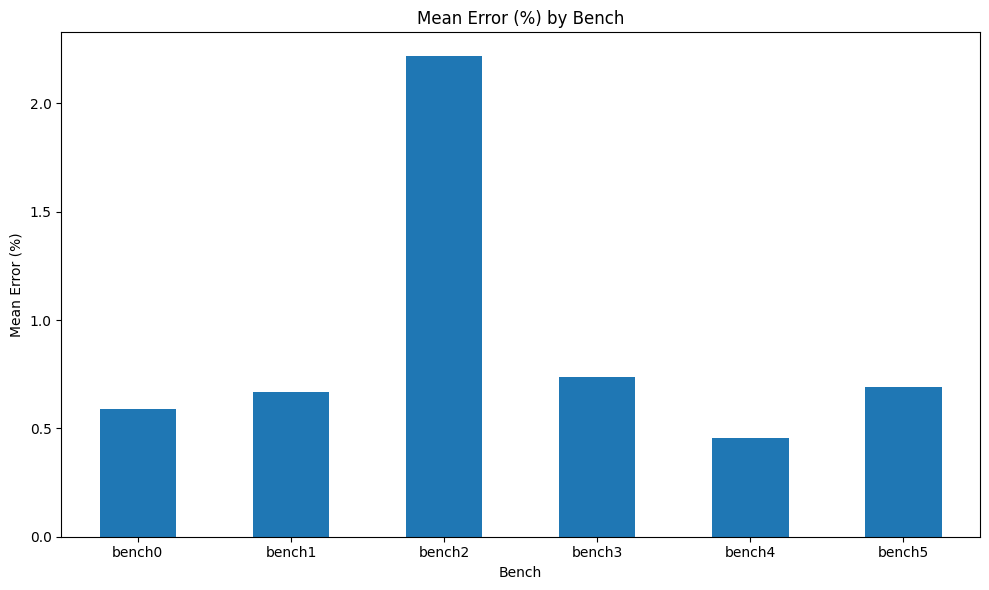

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
bench_error = df.groupby('bench')['error'].mean()
bench_error.plot(kind='bar', ax=ax)
ax.set_xlabel('Bench')
ax.set_ylabel('Mean Error (%)')
ax.set_title('Mean Error (%) by Bench')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("results/serializer/serializer_bench_error.png", bbox_inches='tight')

## Pareto Front

### NGSA Search

In [53]:
with open("results/serializer/pareto_front.json", "r") as f:
    pareto_front = json.load(f)

In [54]:
pareto_points = []
default_pareto_point = {
    'predicted_throughput': pareto_front['baseline']['predicted_throughput_gbits_per_sec'], 
    'predicted_cost': pareto_front['baseline']['predicted_cost']
}
for point in pareto_front['pareto_front']:
    pareto_points.append({
        'predicted_throughput': point['predicted_throughput_gbits_per_sec'],
        'predicted_cost': point['predicted_cost'],
        'validation_candidate': point['validation_candidate']
    })

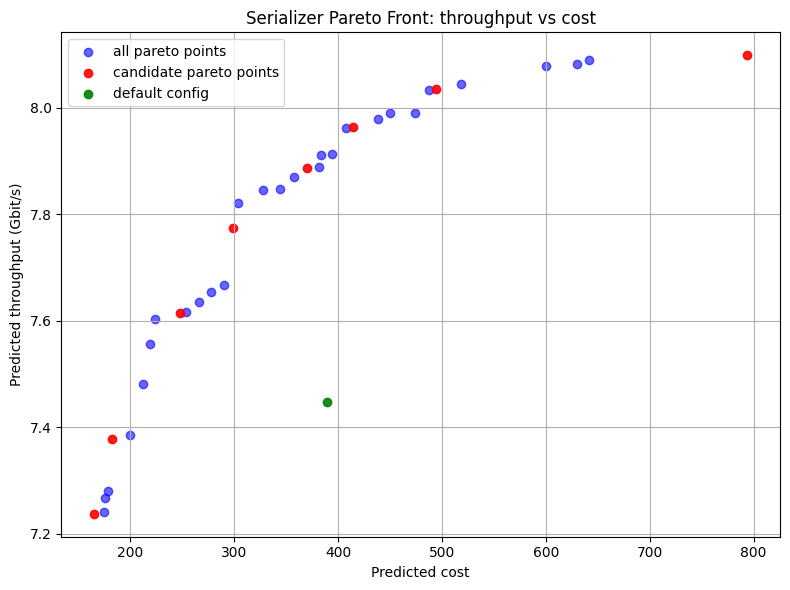

In [55]:
cost = np.array([p["predicted_cost"] for p in pareto_points])
throughput = np.array([p["predicted_throughput"] for p in pareto_points])
is_validation = np.array([p.get("validation_candidate", False) for p in pareto_points])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost[~is_validation], throughput[~is_validation], c="blue", label="all pareto points", alpha=0.6)
ax.scatter(cost[is_validation], throughput[is_validation], c="red", label="candidate pareto points", alpha=0.9)

ax.scatter(default_pareto_point['predicted_cost'], default_pareto_point['predicted_throughput'], c="green", label="default config", alpha=0.9)

ax.set_xlabel("Predicted cost")
ax.set_ylabel("Predicted throughput (Gbit/s)")
ax.set_title("Serializer Pareto Front: throughput vs cost")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
fig.savefig("results/serializer/serializer_throughput_vs_cost.png", bbox_inches="tight")

### Exhaustive Search

In [10]:
with open("results/hpb_only/serializer_train_only/exhaustive_pareto_front.json", "r") as f:
    pareto_front = json.load(f)

In [11]:
pareto_points = []
default_pareto_point = {
    'predicted_throughput': pareto_front['baseline']['predicted_throughput_gbits_per_sec'], 
    'predicted_cost': pareto_front['baseline']['predicted_cost']
}
for point in pareto_front['pareto_front']:
    pareto_points.append({
        'predicted_throughput': point['predicted_throughput_gbits_per_sec'],
        'predicted_cost': point['predicted_cost'],
        'validation_candidate': point['validation_candidate']
    })

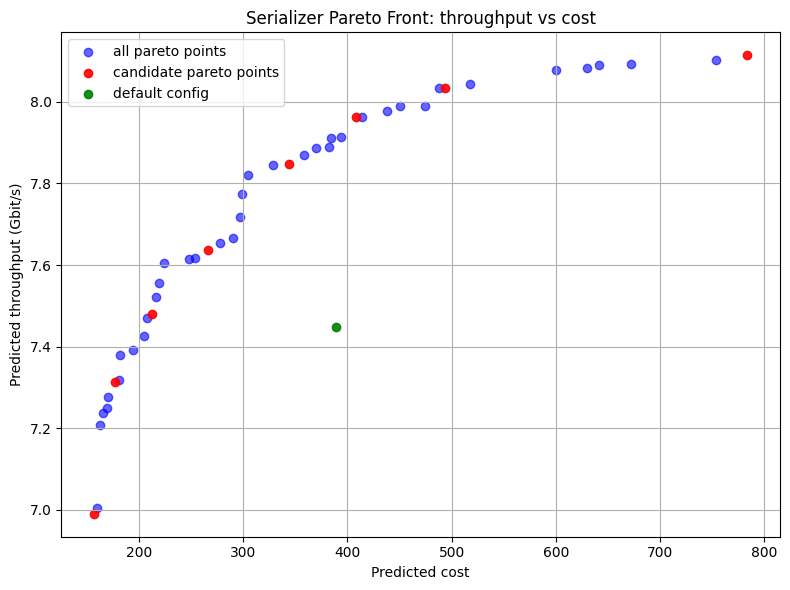

In [12]:
cost = np.array([p["predicted_cost"] for p in pareto_points])
throughput = np.array([p["predicted_throughput"] for p in pareto_points])
is_validation = np.array([p.get("validation_candidate", False) for p in pareto_points])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost[~is_validation], throughput[~is_validation], c="blue", label="all pareto points", alpha=0.6)
ax.scatter(cost[is_validation], throughput[is_validation], c="red", label="candidate pareto points", alpha=0.9)

ax.scatter(default_pareto_point['predicted_cost'], default_pareto_point['predicted_throughput'], c="green", label="default config", alpha=0.9)

ax.set_xlabel("Predicted cost")
ax.set_ylabel("Predicted throughput (Gbit/s)")
ax.set_title("Serializer Pareto Front: throughput vs cost")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
fig.savefig("results/hpb_only/serializer_train_only/exhaustive_pareto_front.png", bbox_inches="tight")

# Synth Sweep

### Constructing deserializer only dataset from partial sweep results

In [ ]:
df = pd.read_csv('data/synth_dataset_partial.csv')

In [ ]:
df_des = df[df['side'] == 'des']

In [ ]:
df_des.shape

(3861, 90)

In [ ]:
df_des.to_csv('data/synth/des_synth_dataset.csv', index=False)

In [ ]:
df_des.groupby('bench').size()[['bench0', 'bench1', 'bench2', 'bench3', 'bench4', 'bench5']].sum()

np.int64(96)

In [ ]:
df_des_synth = df_des[~df_des['bench'].isin(['bench0', 'bench1', 'bench2', 'bench3', 'bench4', 'bench5'])]
print(df_des_synth.shape)

(3765, 90)


In [ ]:
df_des_synth.to_csv('data/synth/des_synth_only_dataset.csv', index=False)

### Constructing serializer dataset with unique configs
when there are duplicates, keep the synth benchmark vs the hpb benchmarks, since we already collected multiple configs on the hpb benchmarks

In [ ]:
df_ser = df[df['side'] == 'ser']

In [ ]:
duplicate_config_counts = df_ser['config_name'].value_counts()
duplicate_configs = duplicate_config_counts[duplicate_config_counts > 1].index.tolist()
print(f"Number of duplicate configs in ser side: {len(duplicate_configs)}")

Number of duplicate configs in ser side: 1525


In [ ]:
df_ser_unique_configs = df_ser[~df_ser['config_name'].isin(duplicate_configs)]
print(f"Shape of ser dataframe with unique configs: {df_ser_unique_configs.shape}")

Shape of ser dataframe with unique configs: (2570, 90)


In [ ]:
df_dupe_configs_synth = df_ser[df_ser['config_name'].isin(duplicate_configs) & ~df_ser['bench'].isin(['bench0', 'bench1', 'bench2', 'bench3', 'bench4', 'bench5'])]

In [ ]:
assert not any(df_dupe_configs_synth['bench'].value_counts() > 1) 
assert not any(df_dupe_configs_synth['config_name'].value_counts() > 1)

In [ ]:
df_ser_clean = pd.concat([df_ser_unique_configs, df_dupe_configs_synth], ignore_index=True)
print(f"Shape of cleaned ser dataframe: {df_ser_clean.shape}")

Shape of cleaned ser dataframe: (4095, 90)


In [ ]:
assert not any(df_ser_clean['config_name'].duplicated())

In [ ]:
df_ser_clean['bench'].value_counts()

bench
bench2       84
bench3       66
bench0       63
bench4       58
bench1       54
             ..
bench3063     1
bench3065     1
bench3066     1
bench3048     1
bench3059     1
Name: count, Length: 3722, dtype: int64

In [ ]:
df_ser_clean.to_csv('data/synth/ser_dataset.csv', index=False)